# Tic Tac Toe com RL - Igor P. Sguissardi

## Formulação do MDP

Este notebook implementa o jogo da velha como um Processo de Decisão de Markov (MDP). O estado (`S`) é o tabuleiro 3x3 representado por um vetor de 9 posições, usando `1` para o agente, `-1` para o oponente e `0` para casas vazias. As ações (`A`) são os índices das casas vazias disponíveis no tabuleiro. A função de recompensa (`R`) retorna `+1` quando o agente vence, `-1` quando o oponente vence e `0` em empates ou passos não terminais. A dinâmica de transição (`P`) aplica primeiro a jogada do agente e, se o jogo ainda não terminou, simula uma jogada aleatória válida do oponente.

In [1]:
import random
import subprocess
import sys
import numpy as np


class TicTacToeEnv:
    """
    Ambiente de Reinforcement Learning para o jogo da velha, implementado do zero.

    Este ambiente modela formalmente um MDP:
    - S: estados possíveis do tabuleiro.
    - A: ações válidas em cada estado.
    - R: recompensa após cada transição.
    - P: dinâmica de transição entre estados.
    """

    AGENT = 1
    OPPONENT = -1
    EMPTY = 0

    WINNING_LINES = (
        (0, 1, 2),  # linha superior
        (3, 4, 5),  # linha do meio
        (6, 7, 8),  # linha inferior
        (0, 3, 6),  # coluna esquerda
        (1, 4, 7),  # coluna do meio
        (2, 5, 8),  # coluna direita
        (0, 4, 8),  # diagonal principal
        (2, 4, 6),  # diagonal secundária
    )

    def __init__(self):
        # Estado inicial do MDP: tabuleiro vazio com 9 posições.
        self.board = np.zeros(9, dtype=int)
        self.done = False

    def reset(self):
        """
        Reinicia o ambiente para o estado inicial.

        Returns:
            Cópia do tabuleiro vazio, ou seja, o estado inicial S0.
        """
        self.board = np.zeros(9, dtype=int)
        self.done = False
        return self.board.copy()

    def get_state_hash(self):
        """
        Retorna uma representação imutável do estado atual.

        Esse método é importante para Q-learning tabular, pois permite usar
        o estado como chave de dicionário nas atualizações de Bellman.
        """
        return tuple(self.board.tolist())

    def get_available_actions(self):
        """
        Componente A do MDP: retorna as ações válidas no estado atual.

        Cada ação é um índice entre 0 e 8 que representa uma casa vazia.
        """
        return [index for index, value in enumerate(self.board) if value == self.EMPTY]

    def check_winner(self):
        """
        Verifica se algum jogador atingiu uma condição terminal de vitória.

        Returns:
            1 se o agente venceu.
            -1 se o oponente venceu.
            0 se ainda não há vencedor.
        """
        for line in self.WINNING_LINES:
            line_sum = int(sum(self.board[index] for index in line))

            if line_sum == 3 * self.AGENT:
                return self.AGENT

            if line_sum == 3 * self.OPPONENT:
                return self.OPPONENT

        return self.EMPTY

    def _is_draw(self):
        """
        Um empate ocorre quando não há vencedor e não existem ações válidas.
        """
        return self.check_winner() == self.EMPTY and len(self.get_available_actions()) == 0

    def step(self, action):
        """
        Componente P do MDP: executa uma transição a partir da ação do agente.

        Sequência da transição:
        1. O agente marca a posição escolhida com 1.
        2. O ambiente verifica recompensa terminal para vitória ou empate.
        3. Se o jogo continua, o oponente escolhe uma ação válida aleatória.
        4. O ambiente verifica novamente vitória, empate ou passo não terminal.

        Args:
            action: índice inteiro entre 0 e 8 escolhido pelo agente.

        Returns:
            next_state: cópia do novo estado do tabuleiro.
            reward: recompensa R da transição.
            done: indica se o episódio terminou.
        """
        if self.done:
            raise RuntimeError("O episódio terminou. Chame reset() antes de executar outro step().")

        if action not in range(9):
            raise ValueError("A ação deve ser um índice inteiro entre 0 e 8.")

        if self.board[action] != self.EMPTY:
            raise ValueError("Ação inválida: a casa escolhida já está ocupada.")

        # Transição do agente: aplica a ação escolhida no estado atual.
        self.board[action] = self.AGENT

        # Componente R: recompensa terminal positiva se o agente venceu.
        if self.check_winner() == self.AGENT:
            self.done = True
            return self.board.copy(), 1, self.done

        # Componente R: empate gera recompensa 0 e encerra o episódio.
        if self._is_draw():
            self.done = True
            return self.board.copy(), 0, self.done

        # Dinâmica do ambiente: o oponente faz uma jogada aleatória válida.
        opponent_action = random.choice(self.get_available_actions())
        self.board[opponent_action] = self.OPPONENT

        # Componente R: recompensa terminal negativa se o oponente venceu.
        if self.check_winner() == self.OPPONENT:
            self.done = True
            return self.board.copy(), -1, self.done

        # Componente R: empate após a jogada do oponente também retorna 0.
        if self._is_draw():
            self.done = True
            return self.board.copy(), 0, self.done

        # Passo não terminal: recompensa 0 e o episódio continua.
        return self.board.copy(), 0, self.done

    def render(self):
        """
        Visualiza o estado atual do tabuleiro no terminal/notebook.
        """
        symbols = {
            self.AGENT: "X",
            self.OPPONENT: "O",
            self.EMPTY: " ",
        }

        for row in range(3):
            start = row * 3
            cells = [symbols[int(value)] for value in self.board[start:start + 3]]
            print(f" {cells[0]} | {cells[1]} | {cells[2]} ")

            if row < 2:
                print("---+---+---")


## Sanity check

O laço abaixo executa um episódio completo usando ações aleatórias para o agente. A cada iteração, selecionamos uma ação válida, aplicamos `step(action)` e deixamos o ambiente responder com a jogada aleatória do oponente. O objetivo do teste nesse patamar ainda é apenas verificar se o ambiente inicializa corretamente, respeita ações válidas, avança as transições do MDP, detecta vitória/empate e retorna uma recompensa final coerente.

In [2]:
random.seed(42)

env = TicTacToeEnv()
state = env.reset()
done = False
final_reward = 0
step_count = 0

while not done:
    # O agente aleatório escolhe apenas ações disponíveis no estado atual.
    action = random.choice(env.get_available_actions())

    # O ambiente aplica a ação do agente, simula o oponente e retorna S', R e done.
    state, final_reward, done = env.step(action)
    step_count += 1

print("Tabuleiro final:")
env.render()
print(f"\nHash do estado final: {env.get_state_hash()}")
print(f"Quantidade de passos do agente: {step_count}")
print(f"Recompensa final: {final_reward}")


Tabuleiro final:
 O | X | X 
---+---+---
 X | O | O 
---+---+---
 O | X | X 

Hash do estado final: (-1, 1, 1, 1, -1, -1, -1, 1, 1)
Quantidade de passos do agente: 5
Recompensa final: 0


## Treinamento com Q-Learning tabular

O Q-Learning tabular estima diretamente a função de valor-ação `Q(s, a)`, que representa o retorno esperado ao executar uma ação `a` em um estado `s` e, em seguida, seguir a melhor política conhecida. Como o jogo da velha possui estados discretos e um conjunto pequeno de ações, uma tabela explícita é suficiente para armazenar os valores aprendidos.

A atualização usada segue a Equação de Otimalidade de Bellman:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[R + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]$$

Nessa expressão, `alpha` controla a velocidade de aprendizado, `gamma` pondera recompensas futuras, `R` é a recompensa observada na transição e `max Q(s', a')` representa a melhor estimativa de retorno a partir do próximo estado.

In [3]:
class QLearningAgent:
    """
    Agente Q-Learning tabular para o jogo da velha.

    A tabela Q mapeia cada estado para um vetor com 9 valores, um para cada
    posição possível do tabuleiro. Estados ainda não visitados são inicializados
    deterministicamente com Q(s, a) = 0 para todas as ações.
    """

    def __init__(
        self,
        alpha=0.1,
        gamma=0.95,
        epsilon=1.0,
        epsilon_decay=0.9995,
        min_epsilon=0.05,
    ):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

        # Inicialização exigida pelo barema: dicionário vazio de valores Q(s, a).
        self.q_table = {}

    def _state_key(self, state):
        """
        Converte o estado do tabuleiro em uma chave imutável para o dicionário.
        """
        return tuple(state.tolist()) if hasattr(state, "tolist") else tuple(state)

    def _ensure_state_exists(self, state):
        """
        Cria uma linha da Q-table com zeros quando o estado ainda não existe.
        """
        state_key = self._state_key(state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(9, dtype=float)

        return state_key

    def choose_action(self, state, available_actions):
        """
        Seleciona uma ação válida usando estratégia epsilon-greedy.
        """
        state_key = self._ensure_state_exists(state)

        if random.random() < self.epsilon:
            return random.choice(available_actions)

        q_values = self.q_table[state_key]
        return max(available_actions, key=lambda action: q_values[action])

    def update(self, state, action, reward, next_state, next_available_actions):
        """
        Aplica explicitamente a Equação de Otimalidade de Bellman:

        Q(s,a) = Q(s,a) + alpha * [R + gamma * max(Q(s',a')) - Q(s,a)]
        """
        state_key = self._ensure_state_exists(state)
        next_state_key = self._ensure_state_exists(next_state)

        current_q = self.q_table[state_key][action]

        if len(next_available_actions) == 0:
            max_next_q = 0.0
        else:
            max_next_q = max(
                self.q_table[next_state_key][next_action]
                for next_action in next_available_actions
            )

        bellman_target = reward + self.gamma * max_next_q
        new_q = current_q + self.alpha * (bellman_target - current_q)

        self.q_table[state_key][action] = new_q

        return abs(new_q - current_q)

    def decay_epsilon(self):
        """
        Reduz a exploração gradualmente, preservando uma taxa mínima.
        """
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)


Final epsilon: 0.0500
Quantidade de estados aprendidos: 2604


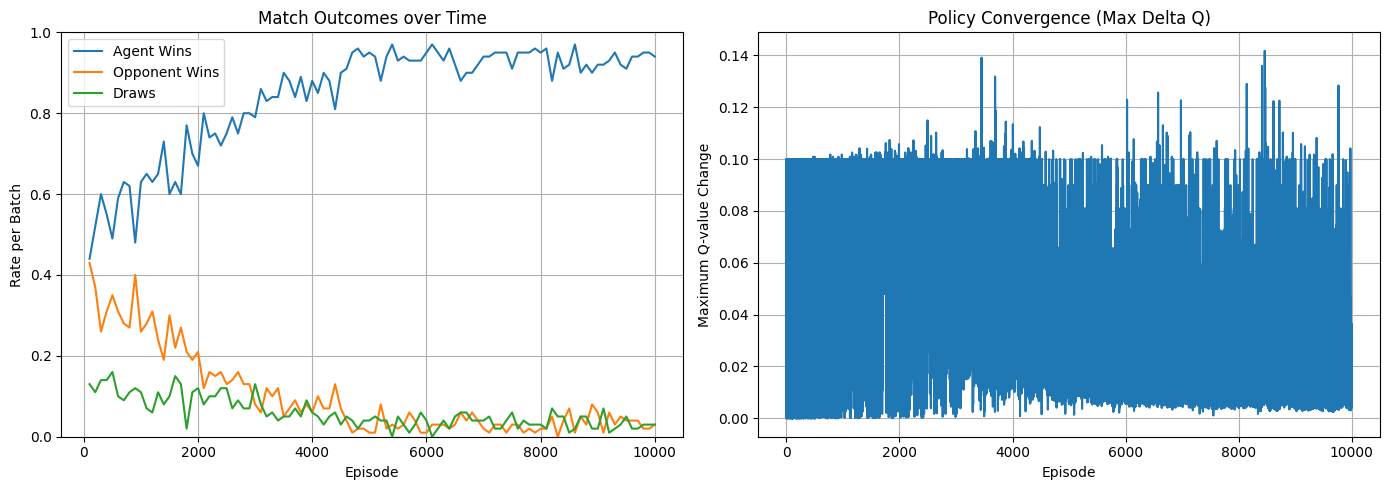

In [4]:
import matplotlib.pyplot as plt


def train(env, agent, episodes=10000, batch_size=100):
    """
    Treina o agente por múltiplos episódios contra o oponente aleatório do ambiente.
    """
    rewards_per_episode = []
    max_delta_per_episode = []

    batch_numbers = []
    agent_wins = []
    opponent_wins = []
    draws = []

    current_agent_wins = 0
    current_opponent_wins = 0
    current_draws = 0

    for episode in range(1, episodes + 1):
        state = env.reset()
        done = False
        episode_reward = 0
        max_delta_q = 0.0

        while not done:
            available_actions = env.get_available_actions()
            action = agent.choose_action(state, available_actions)

            next_state, reward, done = env.step(action)
            next_available_actions = [] if done else env.get_available_actions()

            delta_q = agent.update(
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                next_available_actions=next_available_actions,
            )

            max_delta_q = max(max_delta_q, delta_q)
            episode_reward += reward
            state = next_state

        agent.decay_epsilon()

        rewards_per_episode.append(episode_reward)
        max_delta_per_episode.append(max_delta_q)

        if episode_reward == 1:
            current_agent_wins += 1
        elif episode_reward == -1:
            current_opponent_wins += 1
        else:
            current_draws += 1

        if episode % batch_size == 0:
            batch_numbers.append(episode)
            agent_wins.append(current_agent_wins / batch_size)
            opponent_wins.append(current_opponent_wins / batch_size)
            draws.append(current_draws / batch_size)

            current_agent_wins = 0
            current_opponent_wins = 0
            current_draws = 0

    return {
        "rewards_per_episode": rewards_per_episode,
        "max_delta_per_episode": max_delta_per_episode,
        "batch_numbers": batch_numbers,
        "agent_wins": agent_wins,
        "opponent_wins": opponent_wins,
        "draws": draws,
    }


random.seed(42)
np.random.seed(42)

env = TicTacToeEnv()
agent = QLearningAgent(
    alpha=0.1,
    gamma=0.95,
    epsilon=1.0,
    epsilon_decay=0.9995,
    min_epsilon=0.05,
)

metrics = train(env, agent, episodes=10000, batch_size=100)

print(f"Final epsilon: {agent.epsilon:.4f}")
print(f"Quantidade de estados aprendidos: {len(agent.q_table)}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(metrics["batch_numbers"], metrics["agent_wins"], label="Agent Wins")
plt.plot(metrics["batch_numbers"], metrics["opponent_wins"], label="Opponent Wins")
plt.plot(metrics["batch_numbers"], metrics["draws"], label="Draws")
plt.title("Match Outcomes over Time")
plt.xlabel("Episode")
plt.ylabel("Rate per Batch")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(metrics["max_delta_per_episode"])
plt.title("Policy Convergence (Max Delta Q)")
plt.xlabel("Episode")
plt.ylabel("Maximum Q-value Change")
plt.grid(True)

plt.tight_layout()
plt.show()


## Análise do treinamento

A classe `QLearningAgent` criada acima encapsula a política aprendida por meio de uma Q-table. A estrutura começa como `self.q_table = {}` e cada estado novo recebe um vetor de nove valores iguais a zero, um para cada posição do tabuleiro. A escolha final de ações sempre considera apenas as posições válidas retornadas pelo ambiente.

A Equação de Bellman foi aplicada no método `update()`. O código recupera o valor atual `Q(s, a)`, calcula o alvo `reward + gamma * max_next_q` e corrige o valor antigo por meio de `current_q + alpha * (bellman_target - current_q)`. Quando o episódio termina, `next_available_actions` é vazio e o valor futuro é definido como zero, fazendo com que o alvo seja somente a recompensa terminal observada.

A exploração é controlada pela política epsilon-greedy no método `choose_action()`. No início, `epsilon` alto favorece jogadas aleatórias e amplia a cobertura dos estados. Ao fim de cada episódio, `decay_epsilon()` reduz esse valor multiplicativamente até `min_epsilon`, deslocando gradualmente o comportamento do agente de exploração para exploração da política aprendida.

O gráfico `Match Outcomes over Time` mostra a proporção de vitórias do agente, vitórias do oponente e empates em lotes de episódios. Em um treinamento efetivo, espera-se que a taxa de vitórias do agente aumente e que a taxa de derrotas diminua. O gráfico `Policy Convergence (Max Delta Q)` registra a maior alteração de Q-value em cada episódio; quedas nesse valor indicam que as atualizações de Bellman estão ficando menores e que a política está se aproximando de uma região mais estável.